In [16]:
# %%
# PART 1 — Paths, imports, configuration

import os

# Paths
DATA_DIR = "/scratch/processed"
CSV_PATH = os.path.join(DATA_DIR, "trainLabels.csv")
IMAGE_DIR = DATA_DIR
OUTPUT_DIR = os.path.join(DATA_DIR, "outputs_final")
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(f"{OUTPUT_DIR}/plots", exist_ok=True)
os.makedirs(f"{OUTPUT_DIR}/checkpoints", exist_ok=True)

# Per-epoch CSV log
HISTORY_PATH = os.path.join(OUTPUT_DIR, "training_history.csv")

print("DATA_DIR exists:", os.path.exists(DATA_DIR))
print("CSV_PATH:", CSV_PATH)
print("IMAGE_DIR:", IMAGE_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)

# Imports
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import Counter
import warnings
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, WeightedRandomSampler
from torch.optim import AdamW
from torch.optim.lr_scheduler import SequentialLR, LinearLR, CosineAnnealingLR
from torchvision import transforms

from sklearn.metrics import (
    cohen_kappa_score, confusion_matrix, classification_report,
    f1_score, roc_curve, auc
)
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import train_test_split
from tqdm import tqdm

import timm

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# Configuration
SEED            = 42
IMAGE_SIZE      = 224
BATCH_SIZE      = 32
NUM_EPOCHS      = 30
LR_BACKBONE     = 3e-6
LR_HEAD         = 3e-5
WEIGHT_DECAY    = 0.01
VAL_SPLIT       = 0.15
NUM_WORKERS     = 1
LABEL_SMOOTHING = 0.1
PATIENCE        = 7
ACCUMULATION    = 2

CLASS_NAMES = ["No DR", "Mild", "Moderate", "Severe", "Proliferative"]
NUM_CLASSES = 5

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

import random
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

print("Device:", device)
print("Student: Balaji Periyadurai | URN: 6962046")

DATA_DIR exists: True
CSV_PATH: /scratch/processed/trainLabels.csv
IMAGE_DIR: /scratch/processed
OUTPUT_DIR: /scratch/processed/outputs_final
PyTorch: 2.7.1+cu118
CUDA available: True
GPU: NVIDIA RTX A4000
Device: cuda
Student: Balaji Periyadurai | URN: 6962046


Total images: 35126
Columns: ['image', 'level']
      image  level
0   10_left      0
1  10_right      0
2   13_left      0
3  13_right      0
4   15_left      1

Class distribution:
  Class 0 (No DR): 25810 images (73.5%)
  Class 1 (Mild): 2443 images (7.0%)
  Class 2 (Moderate): 5292 images (15.1%)
  Class 3 (Severe): 873 images (2.5%)
  Class 4 (Proliferative): 708 images (2.0%)


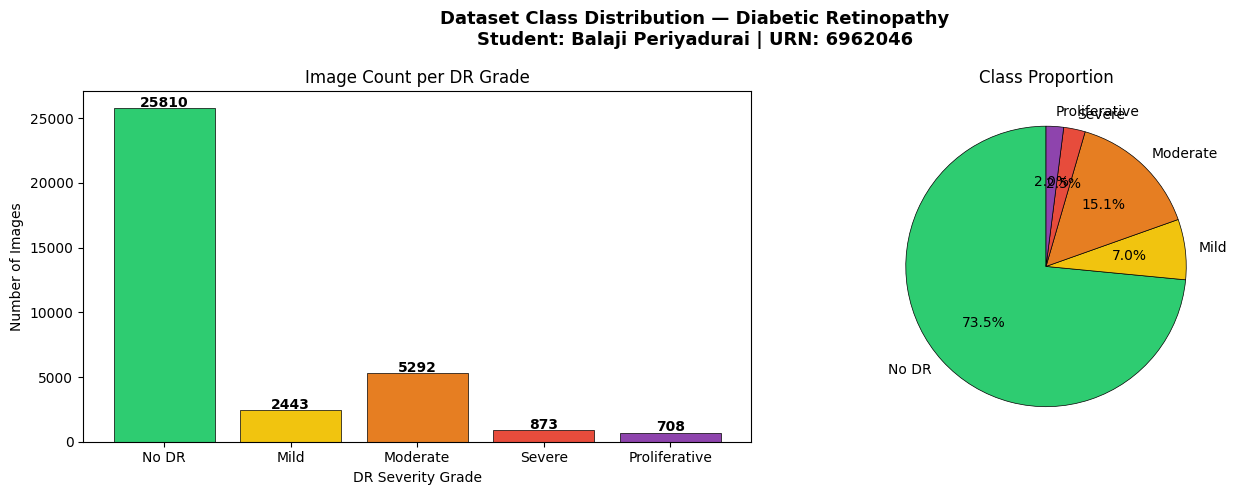

Class distribution plot saved!


In [17]:
# %%
# PART 2 — Dataset visualisation: class distribution

df = pd.read_csv(CSV_PATH)
print(f"Total images: {len(df)}")
print(f"Columns: {df.columns.tolist()}")
print(df.head())

counts = df["level"].value_counts().sort_index()
print("\nClass distribution:")
for i, name in enumerate(CLASS_NAMES):
    print(f"  Class {i} ({name}): {counts.get(i, 0)} images "
          f"({counts.get(i, 0)/len(df)*100:.1f}%)")

colors = ["#2ecc71", "#f1c40f", "#e67e22", "#e74c3c", "#8e44ad"]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Dataset Class Distribution — Diabetic Retinopathy\n"
             "Student: Balaji Periyadurai | URN: 6962046",
             fontsize=13, fontweight="bold")

bars = axes[0].bar(CLASS_NAMES, counts.values, color=colors, edgecolor="black", linewidth=0.5)
axes[0].set_title("Image Count per DR Grade")
axes[0].set_xlabel("DR Severity Grade")
axes[0].set_ylabel("Number of Images")
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 str(val), ha="center", fontweight="bold")

axes[1].pie(counts.values, labels=CLASS_NAMES, colors=colors,
            autopct="%1.1f%%", startangle=90,
            wedgeprops=dict(edgecolor="black", linewidth=0.5))
axes[1].set_title("Class Proportion")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/plots/class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Class distribution plot saved!")

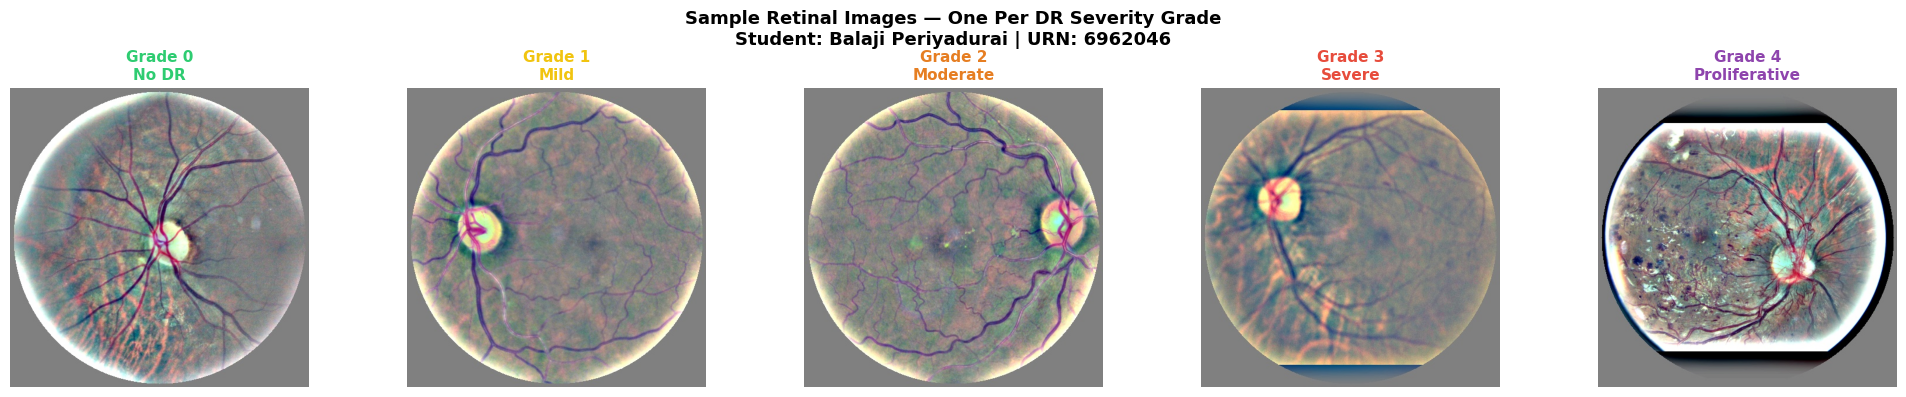

Sample images plot saved!


In [18]:
# %%
# PART 3 — Sample images per DR grade

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.suptitle("Sample Retinal Images — One Per DR Severity Grade\n"
             "Student: Balaji Periyadurai | URN: 6962046",
             fontsize=13, fontweight="bold")

colors = ["#2ecc71", "#f1c40f", "#e67e22", "#e74c3c", "#8e44ad"]

for grade in range(5):
    subset = df[df["level"] == grade]
    img_name = subset.iloc[0]["image"]

    img_path = None
    for ext in [".jpeg", ".jpg", ".png"]:
        candidate = os.path.join(IMAGE_DIR, img_name + ext)
        if os.path.exists(candidate):
            img_path = candidate
            break

    if img_path is None:
        print(f"Warning: no image found for {img_name} (grade {grade})")
        axes[grade].axis("off")
        continue

    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    axes[grade].imshow(image)
    axes[grade].set_title(f"Grade {grade}\n{CLASS_NAMES[grade]}",
                          fontsize=11, fontweight="bold",
                          color=colors[grade])
    axes[grade].axis("off")

    for spine in axes[grade].spines.values():
        spine.set_edgecolor(colors[grade])
        spine.set_linewidth(3)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/plots/sample_images.png", dpi=150, bbox_inches="tight")
plt.show()
print("Sample images plot saved!")

In [19]:
# %%
# PART 4 — Dataset class, transforms, loaders (stratified split)

from torchvision import transforms

def get_transforms(image_size=IMAGE_SIZE, mode="train"):
    if mode == "train":
        return transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.RandomRotation(45),
            transforms.ColorJitter(brightness=0.2, contrast=0.2,
                                   saturation=0.1, hue=0.05),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406],
                                 [0.229, 0.224, 0.225]),
        ])
    else:
        return transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406],
                                 [0.229, 0.224, 0.225]),
        ])

class DRDataset(torch.utils.data.Dataset):
    def __init__(self, csv_path, image_dir, transform=None):
        self.df        = pd.read_csv(csv_path)
        self.image_dir = image_dir
        self.transform = transform
        self.samples   = []

        for _, row in self.df.iterrows():
            img_name = str(row["image"])
            label    = int(row["level"])
            for ext in [".jpeg", ".jpg", ".png"]:
                img_path = os.path.join(image_dir, img_name + ext)
                if os.path.exists(img_path):
                    self.samples.append((img_path, label))
                    break

        print(f"Dataset loaded: {len(self.samples)} images")
        counts = Counter(label for _, label in self.samples)
        for i, name in enumerate(CLASS_NAMES):
            print(f"  Class {i} ({name}): {counts.get(i, 0)}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = Image.fromarray(image)
        if self.transform:
            image = self.transform(image)
        return image, label

    def get_labels(self):
        return [label for _, label in self.samples]

class SubsetWithTransform(torch.utils.data.Dataset):
    def __init__(self, subset, transform):
        self.subset    = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        img_path, label = self.subset.dataset.samples[self.subset.indices[idx]]
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = Image.fromarray(image)
        if self.transform:
            image = self.transform(image)
        return image, label

def get_sampler(labels):
    counts         = np.bincount(labels)
    class_weights  = 1.0 / np.sqrt(counts.astype(float))
    sample_weights = [class_weights[l] for l in labels]
    return WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

def stratified_train_val_split(labels, val_fraction=0.15, seed=SEED):
    indices = np.arange(len(labels))
    train_idx, val_idx = train_test_split(
        indices,
        test_size=val_fraction,
        stratify=labels,
        random_state=seed,
        shuffle=True,
    )
    return train_idx.tolist(), val_idx.tolist()

print("Loading dataset...")
full_dataset = DRDataset(CSV_PATH, IMAGE_DIR,
                         transform=get_transforms(IMAGE_SIZE, "train"))

all_labels = full_dataset.get_labels()
train_indices, val_indices = stratified_train_val_split(all_labels, val_fraction=VAL_SPLIT, seed=SEED)

train_size = len(train_indices)
val_size   = len(val_indices)

train_ds = torch.utils.data.Subset(full_dataset, train_indices)
val_ds   = torch.utils.data.Subset(full_dataset, val_indices)
val_ds_clean = SubsetWithTransform(val_ds, get_transforms(IMAGE_SIZE, "val"))

train_labels = [all_labels[i] for i in train_indices]
sampler      = get_sampler(train_labels)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds_clean, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print(f"\nTrain: {train_size} images | Val: {val_size} images")
print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

Loading dataset...
Dataset loaded: 35126 images
  Class 0 (No DR): 25810
  Class 1 (Mild): 2443
  Class 2 (Moderate): 5292
  Class 3 (Severe): 873
  Class 4 (Proliferative): 708

Train: 29857 images | Val: 5269 images
Train batches: 934 | Val batches: 165


In [20]:
# %%
# PART 5 — Model: tf_EfficientNetV2-S + loss/optim/scheduler

def build_efficientnetv2_model(num_classes=5, dropout=0.3):
    model = timm.create_model(
        "tf_efficientnetv2_s",
        pretrained=True,
        num_classes=num_classes
    )
    in_features = model.classifier.in_features
    model.classifier = nn.Sequential(
        nn.Dropout(dropout),
        nn.Linear(in_features, num_classes)
    )
    return model

model = build_efficientnetv2_model(NUM_CLASSES, dropout=0.3).to(device)
total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Model: tf_EfficientNetV2-S")
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable:,}")

all_labels   = full_dataset.get_labels()
label_counts = [Counter(all_labels)[i] for i in range(NUM_CLASSES)]
print("Label counts:", label_counts)

counts_arr    = torch.tensor(label_counts, dtype=torch.float)
class_weights = 1.0 / torch.sqrt(counts_arr)
class_weights = (class_weights / class_weights.sum() * NUM_CLASSES).to(device)
print("Class weights:", class_weights.cpu().numpy().round(3))

criterion = nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=LABEL_SMOOTHING
)

optimizer = AdamW(model.parameters(), lr=3e-5, weight_decay=WEIGHT_DECAY)

warmup    = LinearLR(optimizer, start_factor=0.1, end_factor=1.0, total_iters=3)
cosine    = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS - 3, eta_min=1e-7)
scheduler = SequentialLR(optimizer, schedulers=[warmup, cosine], milestones=[3])

from torch.cuda.amp import GradScaler, autocast
scaler = GradScaler(enabled=(device.type == "cuda"))

print("Loss, optimiser and scheduler ready!")

Model: tf_EfficientNetV2-S
Total parameters:     20,183,893
Trainable parameters: 20,183,893
Label counts: [25810, 2443, 5292, 873, 708]
Class weights: [0.279 0.906 0.616 1.516 1.683]
Loss, optimiser and scheduler ready!


In [21]:
# %%
# PART 6 — Training and validation functions

def train_one_epoch(model, loader, optimizer, criterion, device, scaler):
    model.train()
    total_loss = 0
    all_preds, all_labels = [], []
    optimizer.zero_grad()

    for step, (images, labels) in enumerate(tqdm(loader, desc="  Train", leave=False)):
        images, labels = images.to(device), labels.to(device)

        with autocast(enabled=(device.type == "cuda")):
            outputs = model(images)
            loss    = criterion(outputs, labels) / ACCUMULATION

        scaler.scale(loss).backward()

        if (step + 1) % ACCUMULATION == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

        total_loss += loss.item() * ACCUMULATION
        all_preds.extend(outputs.argmax(1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    return total_loss / len(loader), np.array(all_preds), np.array(all_labels)


@torch.no_grad()
def validate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds, all_labels, all_probs = [], [], []

    for images, labels in tqdm(loader, desc="  Val  ", leave=False):
        images, labels = images.to(device), labels.to(device)

        with autocast(enabled=(device.type == "cuda")):
            outputs = model(images)
            loss    = criterion(outputs, labels)

        total_loss += loss.item()
        probs = F.softmax(outputs, dim=1).cpu().numpy()
        all_probs.extend(probs)
        all_preds.extend(outputs.argmax(1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    return (total_loss / len(loader),
            np.array(all_preds),
            np.array(all_labels),
            np.array(all_probs))

print("Training functions defined!")

Training functions defined!


In [22]:
# %%
# PART 7 — Training loop with early stopping + CSV logging

import csv

# Initialise CSV log
with open(HISTORY_PATH, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["epoch", "train_loss", "val_loss", "qwk", "f1_macro", "accuracy"])
print("Will log per-epoch metrics to:", HISTORY_PATH)

best_qwk      = -1.0
no_improve    = 0
train_losses, val_losses, val_qwks = [], [], []
val_preds_final = val_labels_final = val_probs_final = None

print(f"Starting training — max {NUM_EPOCHS} epochs, patience={PATIENCE}\n")

for epoch in range(1, NUM_EPOCHS + 1):
    print(f"Epoch {epoch}/{NUM_EPOCHS}")

    train_loss, _, _ = train_one_epoch(
        model, train_loader, optimizer, criterion, device, scaler
    )
    val_loss, val_preds, val_labels_ep, val_probs = validate(
        model, val_loader, criterion, device
    )
    scheduler.step()

    qwk      = cohen_kappa_score(val_labels_ep, val_preds, weights="quadratic")
    f1_macro = f1_score(val_labels_ep, val_preds, average="macro", zero_division=0)
    acc      = (val_preds == val_labels_ep).mean()

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_qwks.append(qwk)

    with open(HISTORY_PATH, "a", newline="") as f:
        writer = csv.writer(f)
        writer.writerow([epoch, train_loss, val_loss, qwk, f1_macro, acc])

    print(f"  Train loss: {train_loss:.4f} | Val loss: {val_loss:.4f}")
    print(f"  QWK: {qwk:.4f} | F1 macro: {f1_macro:.4f} | Acc: {acc:.4f}")

    if qwk > best_qwk:
        best_qwk         = qwk
        no_improve       = 0
        val_preds_final  = val_preds
        val_labels_final = val_labels_ep
        val_probs_final  = val_probs
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "qwk": qwk,
        }, f"{OUTPUT_DIR}/checkpoints/best_efficientnetv2_s.pth")
        print(f"  ✓ New best QWK {best_qwk:.4f} — saved!")
    else:
        no_improve += 1
        print(f"  No improvement ({no_improve}/{PATIENCE})")
        if no_improve >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch}.")
            break

print(f"\nTraining complete! Best QWK: {best_qwk:.4f}")

Will log per-epoch metrics to: /scratch/processed/outputs_final/training_history.csv
Starting training — max 30 epochs, patience=7

Epoch 1/30


  Train loss: 1.7344 | Val loss: 1.8123
  QWK: 0.0764 | F1 macro: 0.1705 | Acc: 0.3071
  ✓ New best QWK 0.0764 — saved!
Epoch 2/30


  Train loss: 1.5353 | Val loss: 1.6785
  QWK: 0.3385 | F1 macro: 0.2743 | Acc: 0.4792
  ✓ New best QWK 0.3385 — saved!
Epoch 3/30


  Train loss: 1.3942 | Val loss: 1.6077
  QWK: 0.4268 | F1 macro: 0.3311 | Acc: 0.4557
  ✓ New best QWK 0.4268 — saved!
Epoch 4/30


  Train loss: 1.3156 | Val loss: 1.5299
  QWK: 0.5631 | F1 macro: 0.4086 | Acc: 0.6834
  ✓ New best QWK 0.5631 — saved!
Epoch 5/30


...

  Train loss: 0.8429 | Val loss: 1.5382
  QWK: 0.5832 | F1 macro: 0.4741 | Acc: 0.6584
  No improvement (3/7)
Epoch 19/30


  Train loss: 0.8386 | Val loss: 1.5589
  QWK: 0.5848 | F1 macro: 0.4718 | Acc: 0.6514
  No improvement (4/7)
Epoch 20/30


  Train loss: 0.8164 | Val loss: 1.5602
  QWK: 0.5697 | F1 macro: 0.4815 | Acc: 0.6472
  No improvement (5/7)
Epoch 21/30


  Train loss: 0.8135 | Val loss: 1.5768
  QWK: 0.5782 | F1 macro: 0.4719 | Acc: 0.6527
  No improvement (6/7)
Epoch 22/30


  Train loss: 0.8055 | Val loss: 1.5791
  QWK: 0.5670 | F1 macro: 0.4827 | Acc: 0.6100
  No improvement (7/7)

Early stopping at epoch 22.

Training complete! Best QWK: 0.6456


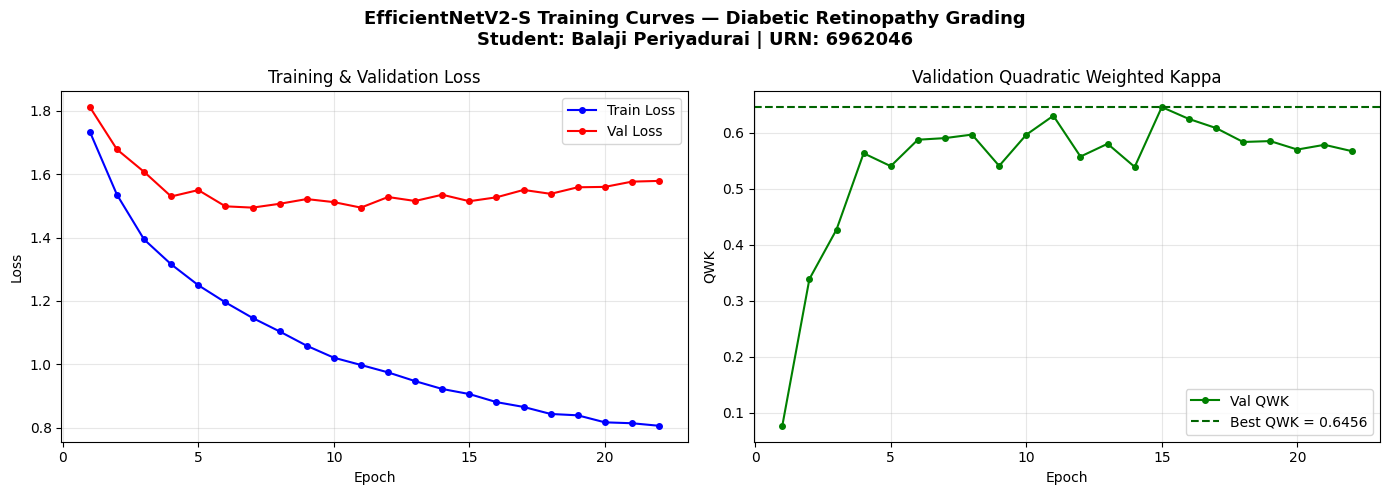

Training curves saved!


In [23]:
# %%
# PART 8 — Training curves

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("EfficientNetV2-S Training Curves — Diabetic Retinopathy Grading\n"
             "Student: Balaji Periyadurai | URN: 6962046",
             fontsize=13, fontweight="bold")

epochs_range = range(1, len(train_losses) + 1)

axes[0].plot(epochs_range, train_losses, "b-o", markersize=4, label="Train Loss")
axes[0].plot(epochs_range, val_losses,   "r-o", markersize=4, label="Val Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training & Validation Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, val_qwks, "g-o", markersize=4, label="Val QWK")
axes[1].axhline(y=best_qwk, color="darkgreen", linestyle="--",
                label=f"Best QWK = {best_qwk:.4f}")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("QWK")
axes[1].set_title("Validation Quadratic Weighted Kappa")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/plots/training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Training curves saved!")

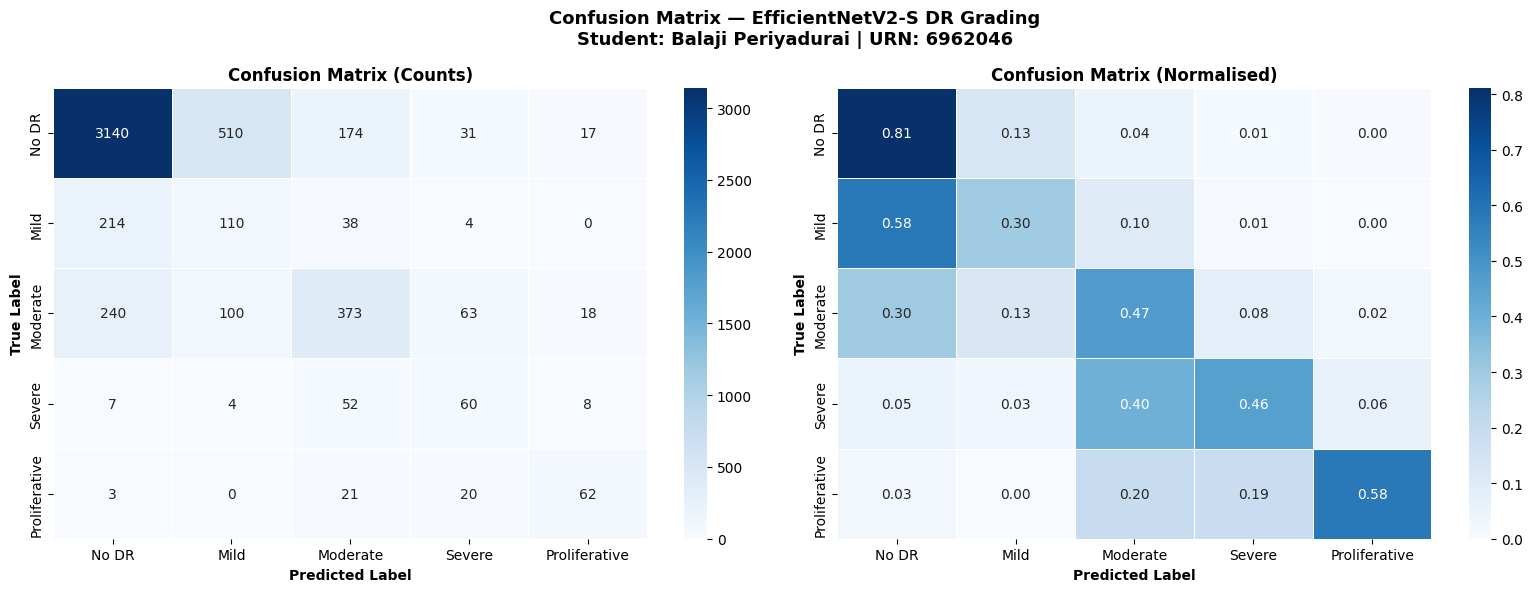


── Classification Report ──
               precision    recall  f1-score   support

        No DR       0.87      0.81      0.84      3872
         Mild       0.15      0.30      0.20       366
     Moderate       0.57      0.47      0.51       794
       Severe       0.34      0.46      0.39       131
Proliferative       0.59      0.58      0.59       106

     accuracy                           0.71      5269
    macro avg       0.50      0.52      0.51      5269
 weighted avg       0.76      0.71      0.73      5269

Overall Accuracy : 0.7108 (71.08%)
Best QWK         : 0.6456
Macro F1         : 0.5063


In [24]:
# %%
# PART 9 — Confusion matrix & classification report

cm      = confusion_matrix(val_labels_final, val_preds_final)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Confusion Matrix — EfficientNetV2-S DR Grading\n"
             "Student: Balaji Periyadurai | URN: 6962046",
             fontsize=13, fontweight="bold")

for ax, data, title, fmt in zip(
    axes,
    [cm, cm_norm],
    ["Confusion Matrix (Counts)", "Confusion Matrix (Normalised)"],
    ["d", ".2f"]
):
    sns.heatmap(data, annot=True, fmt=fmt, cmap="Blues",
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                ax=ax, linewidths=0.5)
    ax.set_xlabel("Predicted Label", fontweight="bold")
    ax.set_ylabel("True Label", fontweight="bold")
    ax.set_title(title, fontweight="bold")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/plots/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n── Classification Report ──")
print(classification_report(val_labels_final, val_preds_final,
                             target_names=CLASS_NAMES, zero_division=0))
acc_final = (val_preds_final == val_labels_final).mean()
print(f"Overall Accuracy : {acc_final:.4f} ({acc_final*100:.2f}%)")
print(f"Best QWK         : {best_qwk:.4f}")
print(f"Macro F1         : {f1_score(val_labels_final, val_preds_final, average='macro', zero_division=0):.4f}")

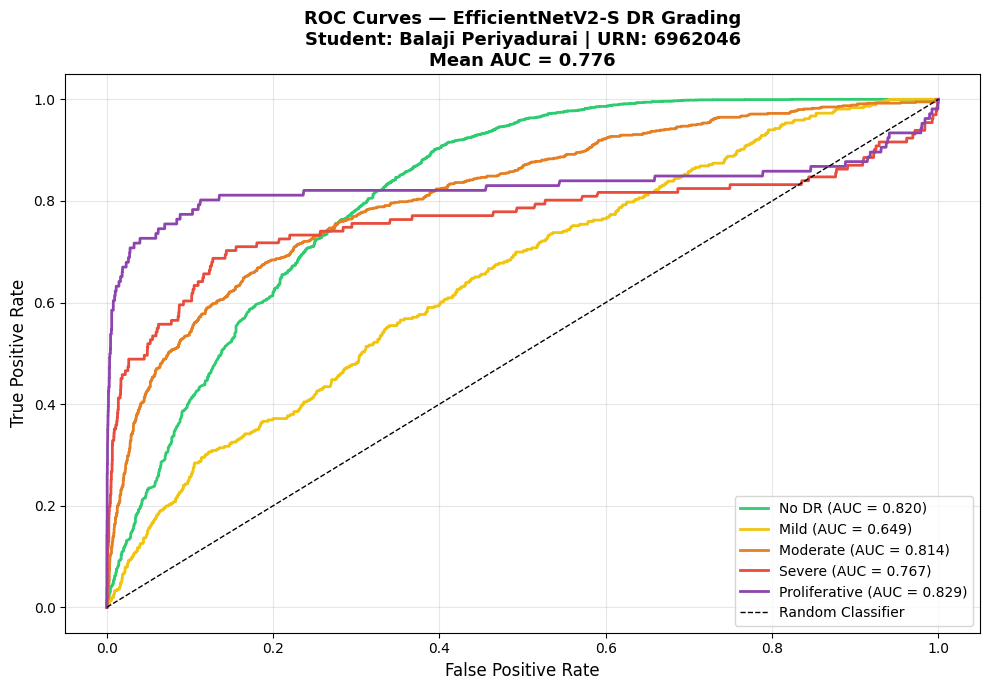

ROC curves saved! Mean AUC: 0.7759


In [25]:
# %%
# PART 10 — ROC Curve + AUC

y_true_bin = label_binarize(val_labels_final, classes=list(range(NUM_CLASSES)))

fig, ax = plt.subplots(figsize=(10, 7))
colors  = ["#2ecc71", "#f1c40f", "#e67e22", "#e74c3c", "#8e44ad"]

auc_scores = []
for i, (name, color) in enumerate(zip(CLASS_NAMES, colors)):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], val_probs_final[:, i])
    auc_val     = auc(fpr, tpr)
    auc_scores.append(auc_val)
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f"{name} (AUC = {auc_val:.3f})")

ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random Classifier")
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title(f"ROC Curves — EfficientNetV2-S DR Grading\n"
             f"Student: Balaji Periyadurai | URN: 6962046\n"
             f"Mean AUC = {np.mean(auc_scores):.3f}",
             fontsize=13, fontweight="bold")
ax.legend(loc="lower right", fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/plots/roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"ROC curves saved! Mean AUC: {np.mean(auc_scores):.4f}")

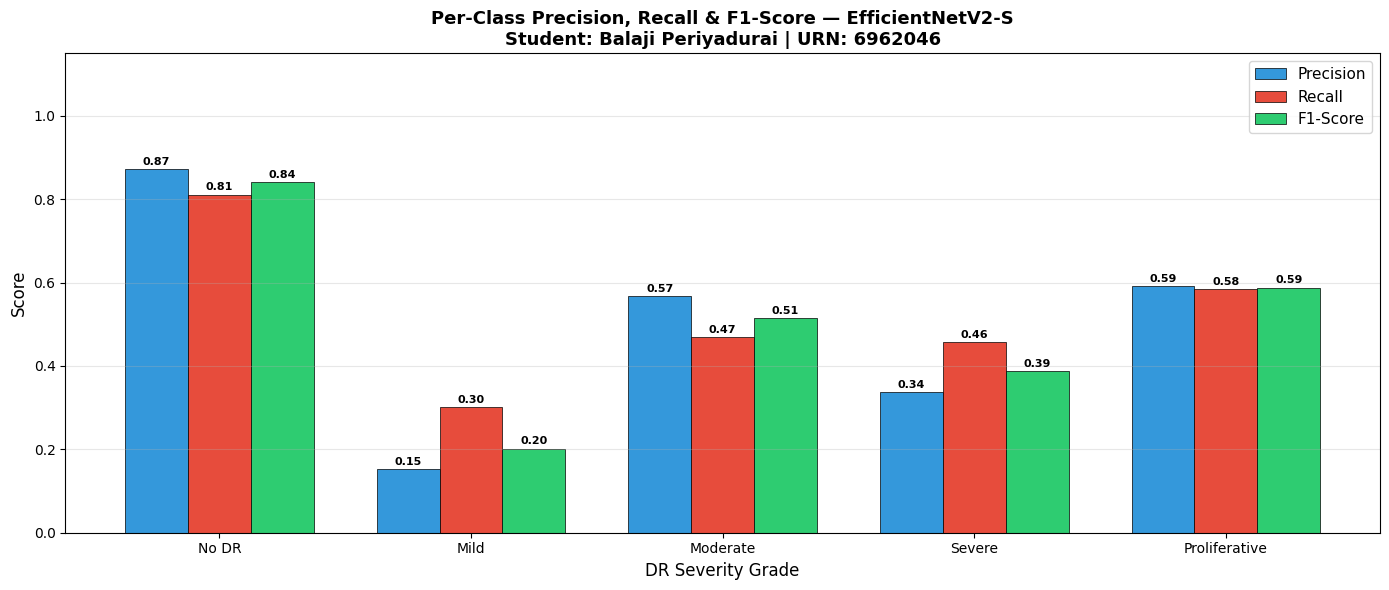

Per-class metrics chart saved!


In [26]:
# %%
# PART 11 — Per-class metrics

report = classification_report(val_labels_final, val_preds_final,
                                target_names=CLASS_NAMES,
                                output_dict=True, zero_division=0)

metrics_data = {
    "Precision": [report[c]["precision"] for c in CLASS_NAMES],
    "Recall":    [report[c]["recall"]    for c in CLASS_NAMES],
    "F1-Score":  [report[c]["f1-score"]  for c in CLASS_NAMES],
}

x      = np.arange(len(CLASS_NAMES))
width  = 0.25
colors = ["#3498db", "#e74c3c", "#2ecc71"]

fig, ax = plt.subplots(figsize=(14, 6))
for i, (metric, vals) in enumerate(metrics_data.items()):
    bars = ax.bar(x + i*width, vals, width, label=metric,
                  color=colors[i], edgecolor="black", linewidth=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{val:.2f}", ha="center", fontsize=8, fontweight="bold")

ax.set_xlabel("DR Severity Grade", fontsize=12)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Per-Class Precision, Recall & F1-Score — EfficientNetV2-S\n"
             "Student: Balaji Periyadurai | URN: 6962046",
             fontsize=13, fontweight="bold")
ax.set_xticks(x + width)
ax.set_xticklabels(CLASS_NAMES)
ax.set_ylim(0, 1.15)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/plots/per_class_metrics.png", dpi=150, bbox_inches="tight")
plt.show()
print("Per-class metrics chart saved!")

Loading checkpoint for GradCAM: /scratch/processed/outputs_final/checkpoints/best_efficientnetv2_s.pth


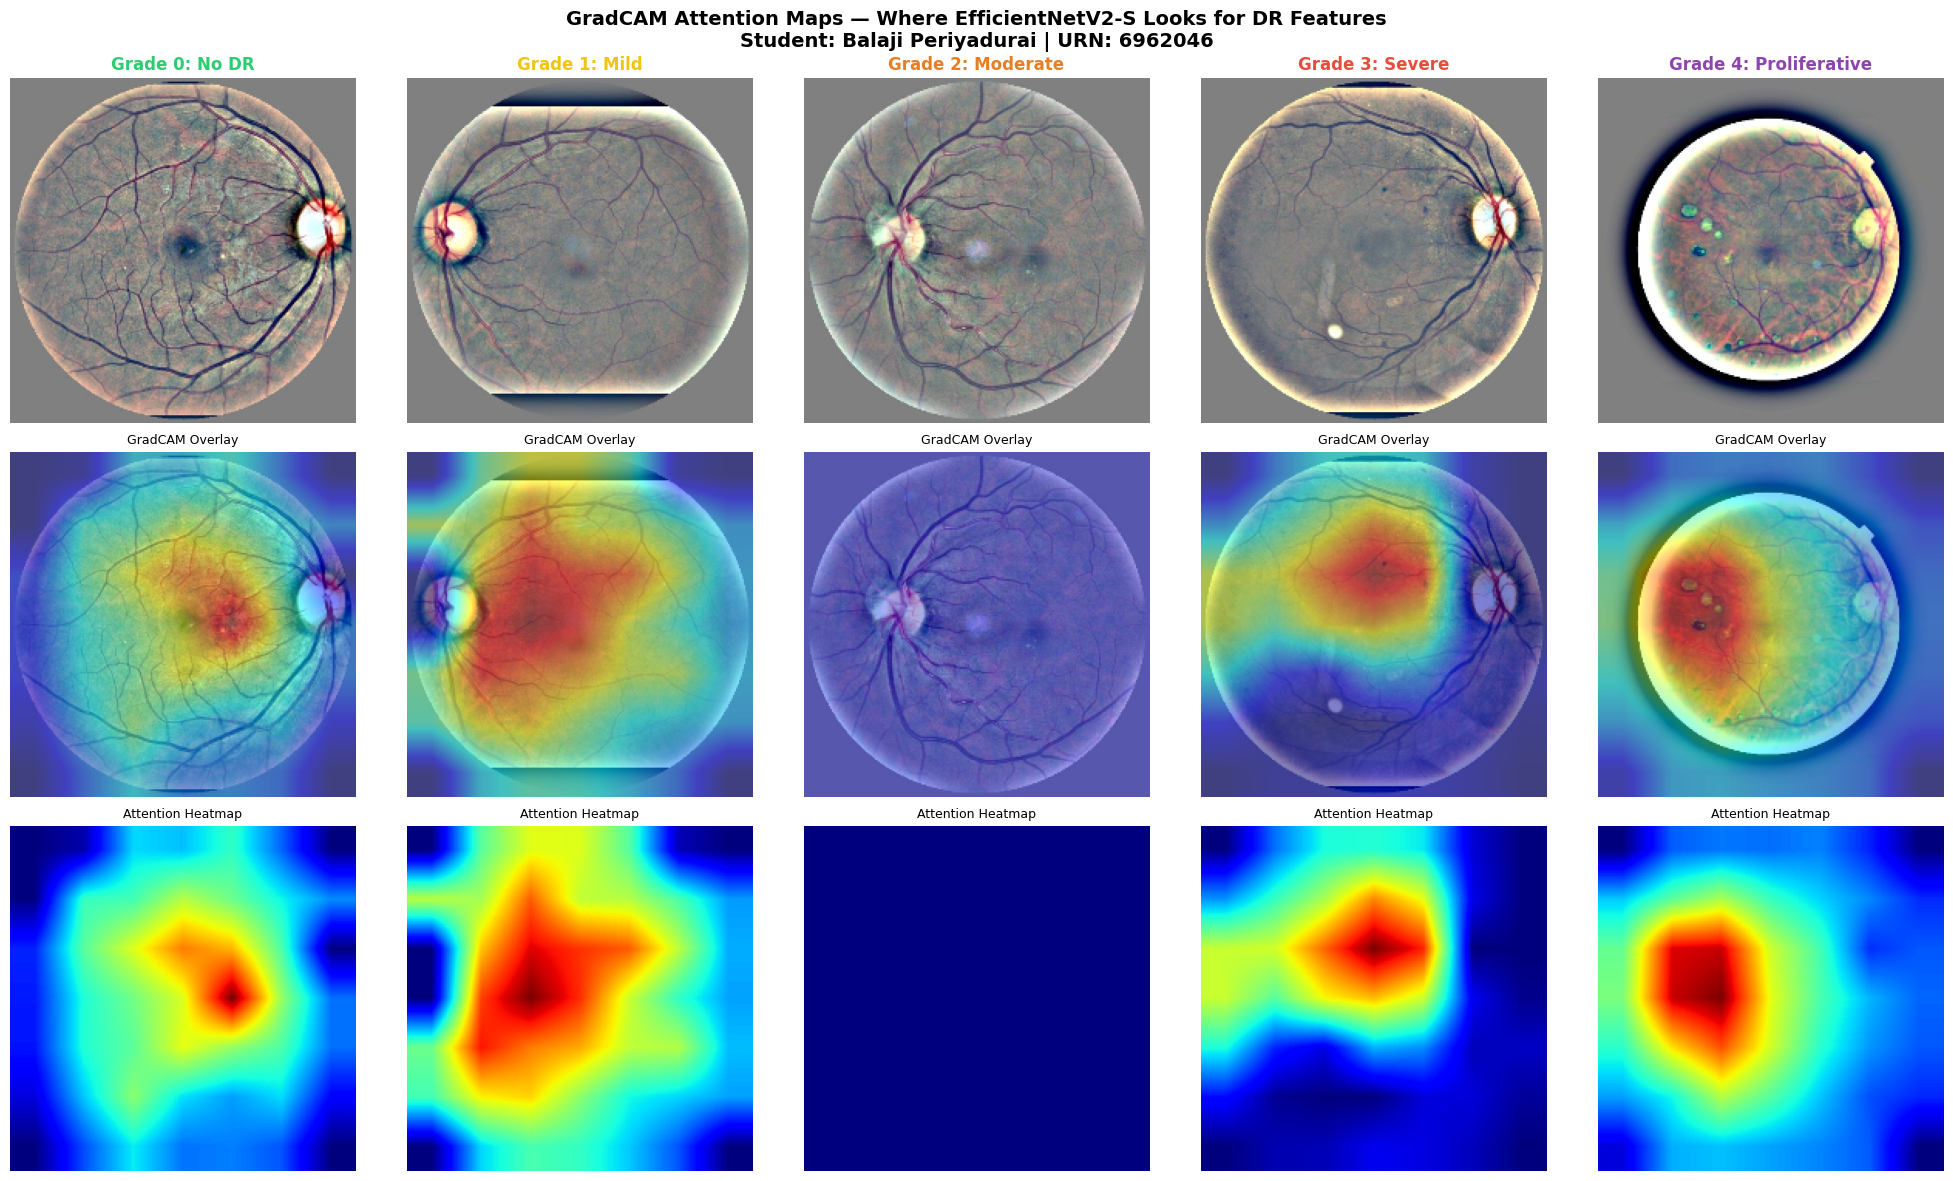

GradCAM heatmaps saved!


In [27]:
# %%
# PART 12 — GradCAM Attention Heatmaps

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

ckpt_path = f"{OUTPUT_DIR}/checkpoints/best_efficientnetv2_s.pth"
print("Loading checkpoint for GradCAM:", ckpt_path)
ckpt = torch.load(ckpt_path, map_location=device)
model.load_state_dict(ckpt["model_state_dict"])
model.to(device)
model.eval()

target_layers = [model.conv_head]
cam = GradCAM(model=model, target_layers=target_layers)

val_transform = get_transforms(IMAGE_SIZE, "val")
fig, axes = plt.subplots(3, 5, figsize=(20, 12))
fig.suptitle("GradCAM Attention Maps — Where EfficientNetV2-S Looks for DR Features\n"
             "Student: Balaji Periyadurai | URN: 6962046",
             fontsize=14, fontweight="bold")

colors = ["#2ecc71", "#f1c40f", "#e67e22", "#e74c3c", "#8e44ad"]

for grade in range(5):
    subset = df[df["level"] == grade]
    if len(subset) == 0:
        print(f"No samples found for grade {grade}")
        for row in range(3):
            axes[row, grade].axis("off")
        continue

    idx = min(3, len(subset) - 1)
    img_name = subset.iloc[idx]["image"]

    img_path = None
    for ext in [".jpeg", ".jpg", ".png"]:
        candidate = os.path.join(IMAGE_DIR, img_name + ext)
        if os.path.exists(candidate):
            img_path = candidate
            break

    if img_path is None:
        print(f"Warning: no image found for {img_name} (grade {grade})")
        for row in range(3):
            axes[row, grade].axis("off")
        continue

    orig = cv2.imread(img_path)
    orig = cv2.cvtColor(orig, cv2.COLOR_BGR2RGB)
    orig_resized = cv2.resize(orig, (IMAGE_SIZE, IMAGE_SIZE))
    orig_float   = orig_resized.astype(np.float32) / 255.0

    input_tensor = val_transform(Image.fromarray(orig_resized)).unsqueeze(0).to(device)
    targets      = [ClassifierOutputTarget(grade)]
    grayscale    = cam(input_tensor=input_tensor, targets=targets)
    cam_image    = show_cam_on_image(orig_float, grayscale[0], use_rgb=True)

    axes[0, grade].imshow(orig_resized)
    axes[0, grade].set_title(f"Grade {grade}: {CLASS_NAMES[grade]}",
                              fontweight="bold", color=colors[grade])
    axes[0, grade].axis("off")

    axes[1, grade].imshow(cam_image)
    axes[1, grade].set_title("GradCAM Overlay", fontsize=9)
    axes[1, grade].axis("off")

    axes[2, grade].imshow(grayscale[0], cmap="jet")
    axes[2, grade].set_title("Attention Heatmap", fontsize=9)
    axes[2, grade].axis("off")

for row, label in enumerate(["Original Image", "GradCAM Overlay", "Attention Heatmap"]):
    axes[row, 0].set_ylabel(label, fontsize=11, fontweight="bold",
                             rotation=90, labelpad=10)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/plots/gradcam_heatmaps_efficientnetv2_s.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("GradCAM heatmaps saved!")

In [28]:
# %%
# PART 13 — Final Summary

acc_final      = (val_preds_final == val_labels_final).mean()
f1_macro_final = f1_score(val_labels_final, val_preds_final, average="macro", zero_division=0)
f1_per_final   = f1_score(val_labels_final, val_preds_final, average=None,   zero_division=0)

print("=" * 60)
print("FINAL RESULTS SUMMARY — EfficientNetV2-S")
print("Student: Balaji Periyadurai | URN: 6962046")
print("Model: tf_EfficientNetV2-S")
print("Dataset: Processed Kaggle DR Dataset")
print("=" * 60)
print(f"Best QWK (primary metric) : {best_qwk:.4f}")
print(f"Overall Accuracy          : {acc_final:.4f} ({acc_final*100:.2f}%)")
print(f"Macro F1                  : {f1_macro_final:.4f}")
print(f"Mean AUC                  : {np.mean(auc_scores):.4f}")
print("-" * 60)
print("Per-class F1 scores:")
for i, (name, score) in enumerate(zip(CLASS_NAMES, f1_per_final)):
    print(f"  Class {i} ({name:15s}): {score:.4f}")
print("-" * 60)
print("Imbalance handling strategies:")
print("  1. Stratified train/val split")
print("  2. Sqrt inverse frequency WeightedRandomSampler")
print("  3. Sqrt inverse frequency class weights in CrossEntropy")
print("  4. Label smoothing = 0.1")
print("  5. LR warmup 3 epochs + cosine annealing")
print("=" * 60)
print(f"\nAll outputs saved to: {OUTPUT_DIR}/plots/")
print("Files saved:")
for f in sorted(os.listdir(os.path.join(OUTPUT_DIR, "plots"))):
    print(f"  {f}")

FINAL RESULTS SUMMARY — EfficientNetV2-S
Student: Balaji Periyadurai | URN: 6962046
Model: tf_EfficientNetV2-S
Dataset: Processed Kaggle DR Dataset
Best QWK (primary metric) : 0.6456
Overall Accuracy          : 0.7108 (71.08%)
Macro F1                  : 0.5063
Mean AUC                  : 0.7759
------------------------------------------------------------
Per-class F1 scores:
  Class 0 (No DR          ): 0.8400
  Class 1 (Mild           ): 0.2018
  Class 2 (Moderate       ): 0.5138
  Class 3 (Severe         ): 0.3883
  Class 4 (Proliferative  ): 0.5877
------------------------------------------------------------
Imbalance handling strategies:
  1. Stratified train/val split
  2. Sqrt inverse frequency WeightedRandomSampler
  3. Sqrt inverse frequency class weights in CrossEntropy
  4. Label smoothing = 0.1
  5. LR warmup 3 epochs + cosine annealing

All outputs saved to: /scratch/processed/outputs_final/plots/
Files saved:
  class_distribution.png
  confusion_matrix.png
  gradcam_heatm